In [1]:
#importing liabraries

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")


In [2]:
df=pd.read_csv("Churn_Modelling.csv")
print("shape of dataset(rows,columns):",df.shape)
df.head()

shape of dataset(rows,columns): (10000, 14)


,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [4]:
df['Exited'].value_counts()

Exited
0    7963
1    2037
Name: count, dtype: int64

In [5]:
#percentage view 
df['Exited'].value_counts(normalize=True)*100

Exited
0    79.63
1    20.37
Name: proportion, dtype: float64

In [6]:
print("Missing values per column:")
print(df.isnull().sum())
df=df.drop(['RowNumber','CustomerId','Surname'],axis=1)
print("\nNew shape:",df.shape)
df.head()

Missing values per column:
RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

New shape: (10000, 11)


,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


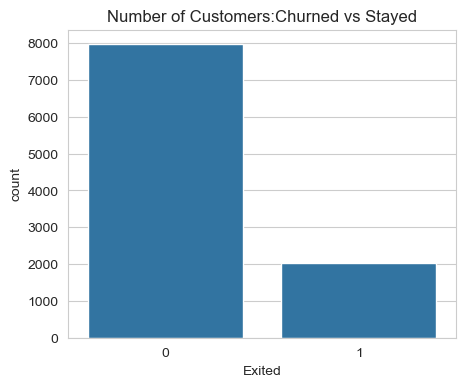

In [7]:
plt.figure(figsize=(5,4))
sns.countplot(x='Exited',data=df)
plt.title('Number of Customers:Churned vs Stayed')
plt.show()           


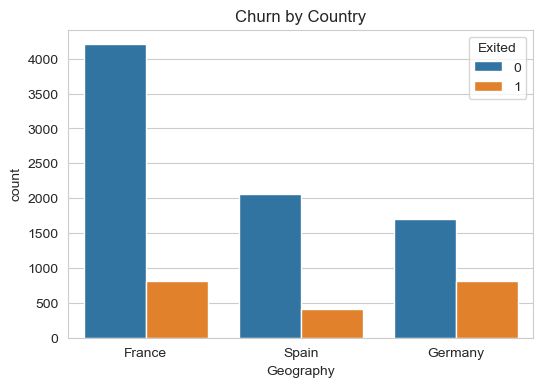

In [8]:
plt.figure(figsize=(6,4))
sns.countplot(x='Geography',hue='Exited',data=df)
plt.title('Churn by Country')
plt.show()

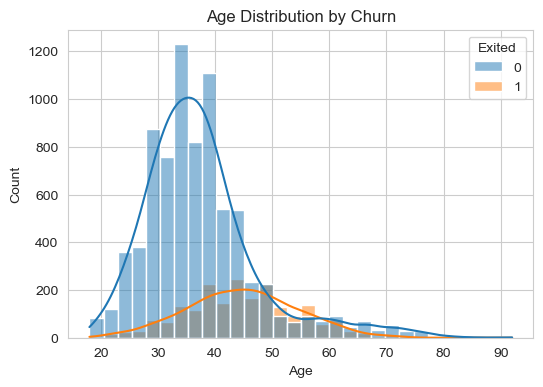

In [9]:
plt.figure(figsize=(6,4))
sns.histplot(data=df,x='Age',hue='Exited',bins=30,kde=True)
plt.title('Age Distribution by Churn')
plt.show()

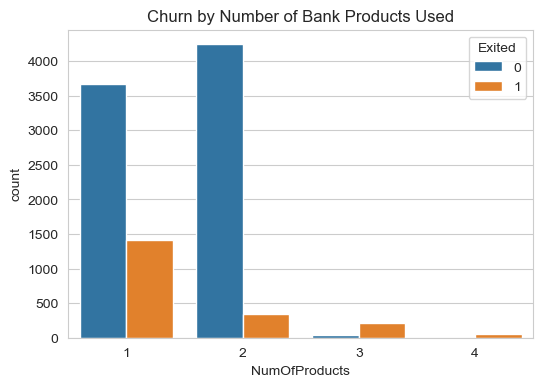

In [10]:
plt.figure(figsize=(6,4))
sns.countplot(x='NumOfProducts',hue='Exited',data=df)
plt.title('Churn by Number of Bank Products Used')
plt.show()

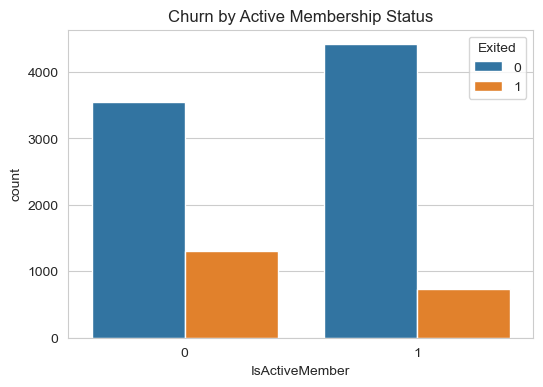

In [18]:
plt.figure(figsize=(6,4))
sns.countplot(x='IsActiveMember',hue='Exited', data=df)
plt.title('Churn by Active Membership Status')
plt.show()

In [11]:
#Converting Text to Numbers

from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
df_encoded=df.copy()

for column in df_encoded.select_dtypes(include='object').columns:
    df_encoded[column]=le.fit_transform(df_encoded[column])
df_encoded.head()    
    
    
    



,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,0,0,42,2,0.00,1,1,1,101348.88,1
1,608,2,0,41,1,83807.86,1,0,1,112542.58,0
2,502,0,0,42,8,159660.80,3,1,0,113931.57,1
3,699,0,0,39,1,0.00,2,0,0,93826.63,0
4,850,2,0,43,2,125510.82,1,1,1,79084.10,0


In [12]:
# SPlitting data  into Training and Testing Sets

from sklearn.model_selection import train_test_split
X = df_encoded.drop('Exited', axis=1)
y = df_encoded['Exited']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])


Training samples: 8000
Testing samples: 2000


In [13]:
# Logistic Regression

from sklearn.linear_model import LogisticRegression
log_model = LogisticRegression(max_iter=5000)
log_model.fit(X_train, y_train)
log_predictions = log_model.predict(X_test)
print("Logistic Regression training complete.")


Logistic Regression training complete.


C:\Users\lukus\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 5000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=5000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [14]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
print("Accuracy:", accuracy_score(y_test, log_predictions))
print()
print("Confusion Matrix:")
print(confusion_matrix(y_test, log_predictions))
print()
print("Classification Report:")
print(classification_report(y_test, log_predictions))


Accuracy: 0.818

Confusion Matrix:
[[1562   45]
 [ 319   74]]

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.97      0.90      1607
           1       0.62      0.19      0.29       393

    accuracy                           0.82      2000
   macro avg       0.73      0.58      0.59      2000
weighted avg       0.79      0.82      0.78      2000



In [15]:
from sklearn.ensemble import RandomForestClassifier
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
rf_predictions = rf_model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, rf_predictions))
print()
print("Confusion Matrix:")
print(confusion_matrix(y_test, rf_predictions))
print()
print("Classification Report:")
print(classification_report(y_test, rf_predictions))


Accuracy: 0.8645

Confusion Matrix:
[[1546   61]
 [ 210  183]]

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.96      0.92      1607
           1       0.75      0.47      0.57       393

    accuracy                           0.86      2000
   macro avg       0.82      0.71      0.75      2000
weighted avg       0.85      0.86      0.85      2000



In [16]:
#Comparing the model
comparison = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest'],
    'Accuracy': [
        accuracy_score(y_test, log_predictions),
        accuracy_score(y_test, rf_predictions)
    ]
})
comparison


,Model,Accuracy
0,Logistic Regression,0.8180
1,Random Forest,0.8645


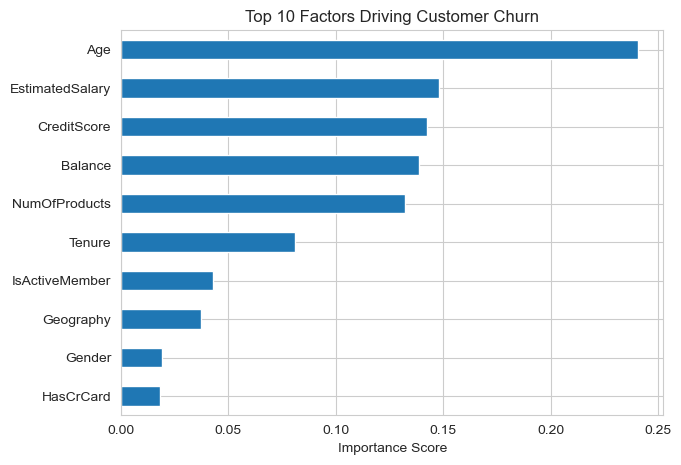

Age                0.240453
EstimatedSalary    0.148004
CreditScore        0.142369
Balance            0.138670
NumOfProducts      0.132061
Tenure             0.080932
IsActiveMember     0.042807
Geography          0.037402
Gender             0.019032
HasCrCard          0.018269
dtype: float64

In [17]:
importances = pd.Series(rf_model.feature_importances_, index=X.columns)
top_features = importances.sort_values(ascending=False).head(10)
plt.figure(figsize=(7,5))
top_features.plot(kind='barh')
plt.title('Top 10 Factors Driving Customer Churn')
plt.xlabel('Importance Score')
plt.gca().invert_yaxis()
plt.show()

top_features


In [18]:
#Hyperparameter Tuning
from sklearn.model_selection import GridSearchCV
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5]
}
grid_search = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=3,
    scoring='accuracy',
    n_jobs=-1
)

grid_search.fit(X_train, y_train)
print("Best parameters found:", grid_search.best_params_)
print("Best cross-validation accuracy:", grid_search.best_score_)

best_rf_model = grid_search.best_estimator_
tuned_predictions = best_rf_model.predict(X_test)
print("Tuned model accuracy on test set:", accuracy_score(y_test, tuned_predictions))


Best parameters found: {'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 100}
Best cross-validation accuracy: 0.8616246675092095
Tuned model accuracy on test set: 0.8655


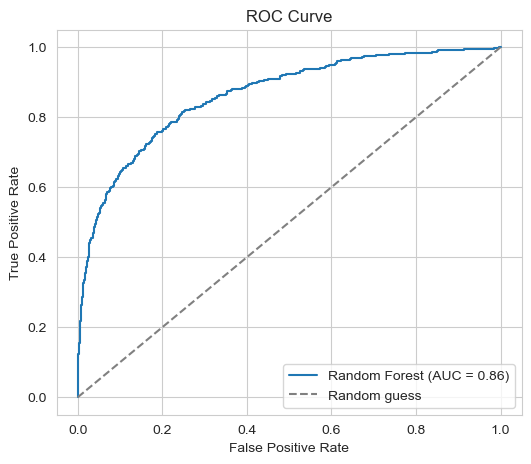

AUC Score: 0.862980186873269


In [19]:
from sklearn.metrics import roc_curve, roc_auc_score
# predict_proba gives probability of churn (class 1), not just Yes/No

probs = best_rf_model.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, probs)
auc_score = roc_auc_score(y_test, probs)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f'Random Forest (AUC = {auc_score:.2f})')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

print("AUC Score:", auc_score)


In [20]:
#Save the Trained Model

import joblib
joblib.dump(best_rf_model, 'churn_model.pkl')
joblib.dump(le, 'label_encoder.pkl')  # note: for a real app you'd save one encoder per column

print("Model saved as 'churn_model.pkl'")


Model saved as 'churn_model.pkl'


In [22]:
#Example:
new_customer = pd.DataFrame([X_test.iloc[0]])
prediction = best_rf_model.predict(new_customer)[0]
probability = best_rf_model.predict_proba(new_customer)[0][1]

print("Prediction:", "Will Churn" if prediction == 1 else "Will Stay")
print(f"Churn Probability: {probability*100:.1f}%")

Prediction: Will Stay
Churn Probability: 5.7%
